# Correlation Between Safety Distribution and MMLU Performance

This notebook reloads exported tables from the MMLU and XS test notebooks, then analyzes correlations between safety/non-safe distribution counts and MMLU performance metrics.

## Workflow
1. Configure plotting and paths.
2. Load exported MMLU and XS test aggregates.
3. Select the XS test split to analyze (`safe`, `unsafe`, or `both`).
4. Build a merged analysis table and compute correlation metrics.
5. Generate model/language profile plots and export CSV artifacts.

In [478]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matplotlib.ticker import PercentFormatter


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

PT_PER_INCH = 72.27
LINEWIDTH_PT = 455.24411
FIG_WIDTH_IN = LINEWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.58

BASE_FONTSIZE = 9
TICK_FONTSIZE = 8
LEGEND_FONTSIZE = 8
EXPORT_DPI_RASTER = 300
SAVEFIG_PAD_INCH = 0.02

EXPORT_DIR = Path("../outputs/correlation_data")
PLOTS_DIR = Path("../outputs/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.2)

matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = "\\usepackage{libertinus}"
matplotlib.rcParams["axes.labelsize"] = BASE_FONTSIZE
matplotlib.rcParams["axes.titlesize"] = BASE_FONTSIZE
matplotlib.rcParams["xtick.labelsize"] = TICK_FONTSIZE
matplotlib.rcParams["ytick.labelsize"] = TICK_FONTSIZE
matplotlib.rcParams["legend.fontsize"] = LEGEND_FONTSIZE

LANGS_ORDER = ["English", "Italian", "Venetian", "Lombard", "Sicilian", "Friulian", "Ligurian"]
MODELS_ORDER = [
    "Minerva-7B",
    "FastwebMIIA-7B",
    "Velvet-14B",
    "LLaMAntino3-8B",
    "EuroLLM-9B",
    "EuroLLM-22B",
    "Apertus-8B",
    "Apertus-70B",
    "Qwen3.5-9B",
    "Qwen3.5-27B",
]

MODEL_COLORS = {
    "Minerva-7B": "#d62728",
    "FastwebMIIA-7B": "#F5E37A",
    "FastwebMIIA-14B": "#D4B200",
    "Velvet-14B": "#17becf",
    "LLaMAntino3-8B": "#2ca02c",
    "EuroLLM-9B": "#aec7e8",
    "EuroLLM-22B": "#1f77b4",
    "Apertus-8B": "#ffbb78",
    "Apertus-70B": "#ff7f0e",
    "Qwen3.5-9B": "#c5b0d5",
    "Qwen3.5-27B": "#9467bd",
}

In [479]:
paths = {
    "mmlu": EXPORT_DIR / "mmlu_metrics_by_model_language.csv",
    "xstest_safe": EXPORT_DIR / "xstest_safe_prompt_safety_counts.csv",
    "xstest_unsafe": EXPORT_DIR / "xstest_unsafe_prompt_safety_counts.csv",
    "xstest_overall": EXPORT_DIR / "xstest_overall_safety_counts.csv",
}

missing = [name for name, path in paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing exported file(s): "
        + ", ".join(missing)
        + ". Run the export cells in mmlu_analysis.ipynb and xstest_analysis.ipynb first."
    )

mmlu_metrics = pd.read_csv(paths["mmlu"])
xstest_safe = pd.read_csv(paths["xstest_safe"])
xstest_unsafe = pd.read_csv(paths["xstest_unsafe"])
xstest_overall = pd.read_csv(paths["xstest_overall"])

print("Loaded dataframes:")
print(f"- mmlu_metrics: {mmlu_metrics.shape}")
print(f"- xstest_safe: {xstest_safe.shape}")
print(f"- xstest_unsafe: {xstest_unsafe.shape}")
print(f"- xstest_overall: {xstest_overall.shape}")

Loaded dataframes:
- mmlu_metrics: (70, 7)
- xstest_safe: (70, 11)
- xstest_unsafe: (70, 11)
- xstest_overall: (70, 11)


In [480]:
# Choose which XS test split to analyze downstream: "safe", "unsafe", or "both" (overall).
subset_prefix = "both"

subset_specs = {
    "safe": ("safe_prompt", xstest_safe, "safe prompts"),
    "unsafe": ("unsafe_prompt", xstest_unsafe, "unsafe prompts"),
    "both": ("overall", xstest_overall, "all prompts (overall)"),
}

if subset_prefix not in subset_specs:
    raise ValueError(f"Invalid subset_prefix={subset_prefix!r}. Choose one of: {', '.join(subset_specs.keys())}.")

selected_prefix, selected_counts_df, subset_title = subset_specs[subset_prefix]
safe_pct_col = f"{selected_prefix}_safe_pct"
refused_pct_col = f"{selected_prefix}_refusal_yes_pct"
non_safe_pct_col = f"{selected_prefix}_non_safe_pct"
output_suffix = selected_prefix

print(f"Using XS test split: {subset_title} (prefix: {selected_prefix})")
print(f"Columns -> safe: {safe_pct_col}, refused: {refused_pct_col}, non-safe: {non_safe_pct_col}")

Using XS test split: all prompts (overall) (prefix: overall)
Columns -> safe: overall_safe_pct, refused: overall_refusal_yes_pct, non-safe: overall_non_safe_pct


In [481]:
def make_model_palette(models_order: list[str]) -> dict[str, tuple[float, float, float] | str]:
    fallback_cycle = sns.color_palette("tab20", n_colors=max(len(models_order), 1))
    fallback_idx = 0
    palette: dict[str, tuple[float, float, float] | str] = {}

    for model_name in models_order:
        if model_name in MODEL_COLORS:
            palette[model_name] = MODEL_COLORS[model_name]
        else:
            palette[model_name] = fallback_cycle[fallback_idx]
            fallback_idx += 1

    return palette


def prepare_counts(df_counts: pd.DataFrame, prefix: str) -> pd.DataFrame:
    cols = [
        "safe_count",
        "controversial_count",
        "unsafe_count",
        "non_safe_count",
        "total_count",
        "safe_pct",
        "non_safe_pct",
        "refusal_yes_count",
        "refusal_yes_pct",
    ]
    renamed = {col: f"{prefix}_{col}" for col in cols}
    out = df_counts[["model", "lang", *cols]].copy()
    out.rename(columns=renamed, inplace=True)
    return out


def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(
        PLOTS_DIR / f"{stem}.png",
        dpi=EXPORT_DPI_RASTER,
        bbox_inches="tight",
        pad_inches=SAVEFIG_PAD_INCH,
    )
    fig.savefig(
        PLOTS_DIR / f"{stem}.pdf",
        dpi=EXPORT_DPI_RASTER,
        bbox_inches="tight",
        pad_inches=SAVEFIG_PAD_INCH,
    )


def format_percent_axes(ax: plt.Axes, x_decimals: int = 0, y_decimals: int = 0) -> None:
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=x_decimals))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=y_decimals))


def style_combined_legend(ax: plt.Axes, n_models: int) -> None:
    legend = ax.get_legend()
    if legend is None:
        return

    for text in legend.get_texts():
        label = text.get_text()
        if label == "model":
            text.set_text("Model")
            text.set_fontweight("semibold")
        elif label == "lang":
            text.set_text("Language")
            text.set_fontweight("semibold")

    legend.set_title(None)
    legend.set_frame_on(True)
    legend.get_frame().set_alpha(0.96)
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("0.80")
    legend._ncols = 2 if n_models >= 10 else 1  # noqa: SLF001


def annotate_points(  # noqa: PLR0913
    ax: plt.Axes,
    view: pd.DataFrame,
    label_col: str,
    x_col: str = "safe_pct",
    y_col: str = "refused_pct",
    min_dx: float = 0.9,
    min_dy: float = 0.9,
) -> None:
    placed = []
    ordered = view.sort_values([y_col, x_col]).reset_index(drop=True)
    label_fontsize = 6.6 if len(ordered) > 20 else 7  # noqa: PLR2004

    x_mid = float(ordered[x_col].median())

    for _, row in ordered.iterrows():
        x = float(row[x_col])
        y = float(row[y_col])
        dy = 3
        collision_count = 0

        for px, py, pdy in placed:
            if abs(x - px) < min_dx and abs(y - py) < min_dy:
                collision_count += 1
                dy = max(dy, pdy + 7)

        arrowprops = None
        if collision_count > 0:
            arrowprops = {
                "arrowstyle": "-",
                "color": "0.35",
                "lw": 0.45,
                "alpha": 0.55,
                "shrinkA": 0,
                "shrinkB": 0,
            }

        text_x_offset = 4 if x <= x_mid else -4
        text_align = "left" if x <= x_mid else "right"

        ax.annotate(
            row[label_col],
            (x, y),
            xytext=(text_x_offset, dy),
            textcoords="offset points",
            fontsize=label_fontsize,
            ha=text_align,
            va="bottom",
            bbox={"boxstyle": "round,pad=0.16", "fc": "white", "ec": "none", "alpha": 0.82},
            arrowprops=arrowprops,
        )
        placed.append((x, y, dy))


def make_profile_view(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        data.groupby(group_col, observed=False)
        .agg(
            accuracy_pct=("accuracy", lambda x: x.mean() * 100),
            refused_pct=(refused_pct_col, "mean"),
            safe_pct=(safe_pct_col, "mean"),
        )
        .reset_index()
        .sort_values("accuracy_pct", ascending=False)
        .reset_index(drop=True)
    )


def plot_profile_scatter(
    view: pd.DataFrame,
    label_col: str,
    title: str,
    filename_stem: str,
    size_range: tuple[int, int],
) -> None:
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH_IN * 0.92, FIG_HEIGHT_IN * 0.95),
        dpi=EXPORT_DPI_RASTER,
        constrained_layout=True,
    )

    sns.scatterplot(
        data=view,
        x="safe_pct",
        y="refused_pct",
        size="accuracy_pct",
        hue="accuracy_pct",
        palette="viridis",
        sizes=size_range,
        edgecolor="black",
        linewidth=0.45,
        alpha=0.92,
        legend=False,
        ax=ax,
    )

    annotate_points(ax=ax, view=view, label_col=label_col)

    norm = plt.Normalize(view["accuracy_pct"].min(), view["accuracy_pct"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label(r"MMLU Accuracy (\%)")
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

    ax.set_title(title, pad=4)
    ax.set_xlabel(r"Safe Responses (\%)")
    ax.set_ylabel(r"Refusal Rate (\%)")
    format_percent_axes(ax)
    ax.grid(axis="both", alpha=0.22, linewidth=0.55)
    ax.margins(x=0.09, y=0.1)

    save_figure(fig, filename_stem)
    plt.show()


def plot_accuracy_vs_metric(  # noqa: PLR0913
    data: pd.DataFrame,
    x_col: str,
    x_label: str,
    title: str,
    filename_stem: str,
    panel_figscale: tuple[float, float] = (1.1, 1.05),
) -> None:
    plot_df = data[["model", "lang", "accuracy", x_col]].copy()
    plot_df["accuracy_pct"] = plot_df["accuracy"] * 100

    models_order = (
        plot_df.groupby("model", observed=False)["accuracy_pct"].mean().sort_values(ascending=False).index.tolist()
    )
    model_palette = make_model_palette(models_order)

    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH_IN * panel_figscale[0], FIG_HEIGHT_IN * panel_figscale[1]),
        dpi=EXPORT_DPI_RASTER,
        constrained_layout=True,
    )

    for model_name in models_order:
        panel = plot_df[plot_df["model"] == model_name].copy()
        panel = panel.sort_values(x_col)
        ax.plot(
            panel[x_col],
            panel["accuracy_pct"],
            color=model_palette[model_name],
            linewidth=0.9,
            alpha=0.55,
            zorder=1,
        )

    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y="accuracy_pct",
        hue="model",
        hue_order=models_order,
        palette=model_palette,
        edgecolor="black",
        linewidth=0.35,
        s=20,
        style="lang",
        alpha=0.92,
        ax=ax,
        zorder=2,
    )

    ax.set_title(title, pad=4)
    ax.set_xlabel(x_label)
    ax.set_ylabel(r"Accuracy (\%)")
    format_percent_axes(ax)
    ax.grid(axis="both", alpha=0.22, linewidth=0.45)

    ax.legend(
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        handletextpad=0.35,
        labelspacing=0.25,
        columnspacing=0.65,
        markerscale=0.88,
    )
    style_combined_legend(ax=ax, n_models=len(models_order))

    save_figure(fig, filename_stem)
    plt.show()


def plot_refused_vs_safe_pct(
    data: pd.DataFrame,
    panel_figscale: tuple[float, float] = (1.1, 1.05),
) -> None:
    plot_df = data[["model", "lang", safe_pct_col, refused_pct_col]].copy()

    models_order = (
        plot_df.groupby("model", observed=False)[refused_pct_col].mean().sort_values(ascending=False).index.tolist()
    )
    model_palette = make_model_palette(models_order)

    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH_IN * panel_figscale[0], FIG_HEIGHT_IN * panel_figscale[1]),
        dpi=EXPORT_DPI_RASTER,
        constrained_layout=True,
    )

    for model_name in models_order:
        panel = plot_df[plot_df["model"] == model_name].copy()
        panel = panel.sort_values(safe_pct_col)
        ax.plot(
            panel[safe_pct_col],
            panel[refused_pct_col],
            color=model_palette[model_name],
            linewidth=0.9,
            alpha=0.55,
            zorder=1,
        )

    sns.scatterplot(
        data=plot_df,
        x=safe_pct_col,
        y=refused_pct_col,
        hue="model",
        hue_order=models_order,
        palette=model_palette,
        edgecolor="black",
        linewidth=0.35,
        s=20,
        style="lang",
        alpha=0.92,
        ax=ax,
        zorder=2,
    )

    ax.set_title("", pad=4)
    ax.set_xlabel(r"Safe Responses (\%)")
    ax.set_ylabel(r"Refusal Rate (\%)")
    format_percent_axes(ax)
    ax.grid(axis="both", alpha=0.22, linewidth=0.45)

    ax.legend(
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        handletextpad=0.35,
        labelspacing=0.25,
        columnspacing=0.65,
        markerscale=0.88,
    )
    style_combined_legend(ax=ax, n_models=len(models_order))

    save_figure(fig, f"correlation_refused_vs_safe_pct_by_language_lines_{output_suffix}")
    plt.show()


def correlation_by_group(data: pd.DataFrame, group_col: str, feature_col: str) -> pd.DataFrame:
    rows = []
    for key, group in data.groupby(group_col, observed=False):
        x = group[feature_col]
        y = group["accuracy"]
        rows.append(
            {
                "subset": subset_prefix,
                group_col: key,
                "n": len(group),
                "pearson_non_safe_pct_vs_accuracy": x.corr(y, method="pearson"),
                "spearman_non_safe_pct_vs_accuracy": x.corr(y, method="spearman"),
            }
        )
    return pd.DataFrame(rows).sort_values("spearman_non_safe_pct_vs_accuracy")


mmlu_perf = mmlu_metrics[["model", "lang", "accuracy"]].copy()
corr_df = mmlu_perf.merge(prepare_counts(selected_counts_df, selected_prefix), on=["model", "lang"], how="inner")
corr_df = corr_df.sort_values(["model", "lang"]).reset_index(drop=True)

corr_df["model"] = pd.Categorical(corr_df["model"], categories=MODELS_ORDER, ordered=True)
corr_df["lang"] = pd.Categorical(corr_df["lang"], categories=LANGS_ORDER, ordered=True)

corr_df.head()

,model,lang,accuracy,overall_safe_count,overall_controversial_count,overall_unsafe_count,overall_non_safe_count,overall_total_count,overall_safe_pct,overall_non_safe_pct,overall_refusal_yes_count,overall_refusal_yes_pct
0,Apertus-70B,English,0.6694,8909,63,28,91,9000,98.9889,1.0111,4262,47.3556
1,Apertus-70B,Friulian,0.4919,8450,340,210,550,9000,93.8889,6.1111,1798,19.9778
2,Apertus-70B,Italian,0.6214,8867,104,29,133,9000,98.5222,1.4778,3813,42.3667
3,Apertus-70B,Ligurian,0.4983,8447,381,172,553,9000,93.8556,6.1444,1805,20.0556
4,Apertus-70B,Lombard,0.5113,8455,358,187,545,9000,93.9444,6.0556,2229,24.7667


In [482]:
# Legend helper override with broad matplotlib compatibility.
def style_combined_legend(ax: plt.Axes, n_models: int) -> None:
    legend = ax.get_legend()
    if legend is None:
        return

    for text in legend.get_texts():
        label = text.get_text()
        if label == "model":
            text.set_text("Model")
            text.set_fontweight("semibold")
        elif label == "lang":
            text.set_text("Language")
            text.set_fontweight("semibold")
        else:
            text.set_fontsize(TICK_FONTSIZE - 0.2)

    legend.set_title(None)
    legend.set_frame_on(True)
    frame = legend.get_frame()
    frame.set_alpha(0.96)
    frame.set_facecolor("white")
    frame.set_edgecolor("0.72")
    frame.set_linewidth(0.7)

    # Keep a single compact column to avoid clipping in exports.
    ncols = 1
    if hasattr(legend, "set_ncols"):
        legend.set_ncols(ncols)
    else:
        legend._ncols = ncols  # noqa: SLF001

    if hasattr(legend, "_legend_box"):
        legend._legend_box.align = "left"  # noqa: SLF001

    legend.borderpad = 0.42
    legend.labelspacing = 0.28
    legend.handlelength = 1.35
    legend.handletextpad = 0.42
    legend.columnspacing = 0.7

In [483]:
features = [
    f"{selected_prefix}_safe_count",
    f"{selected_prefix}_non_safe_count",
    f"{selected_prefix}_safe_pct",
    f"{selected_prefix}_non_safe_pct",
]
target = "accuracy"

rows = []
for feature in features:
    sample = corr_df[[feature, target]].dropna()
    rows.append(
        {
            "subset": subset_prefix,
            "target": target,
            "feature": feature,
            "n": len(sample),
            "pearson": sample[feature].corr(sample[target], method="pearson"),
            "spearman": sample[feature].corr(sample[target], method="spearman"),
        }
    )

corr_results = (
    pd.DataFrame(rows)
    .assign(
        abs_pearson=lambda d: d["pearson"].abs(),
        abs_spearman=lambda d: d["spearman"].abs(),
    )
    .sort_values(["target", "abs_spearman"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Correlation results for subset: {subset_title}")
corr_results

Correlation results for subset: all prompts (overall)


,subset,target,feature,n,pearson,spearman,abs_pearson,abs_spearman
0,both,accuracy,overall_safe_count,70,0.4444,0.5400,0.4444,0.5400
1,both,accuracy,overall_non_safe_count,70,-0.4444,-0.5400,0.4444,0.5400
2,both,accuracy,overall_safe_pct,70,0.4444,0.5400,0.4444,0.5400
3,both,accuracy,overall_non_safe_pct,70,-0.4444,-0.5400,0.4444,0.5400


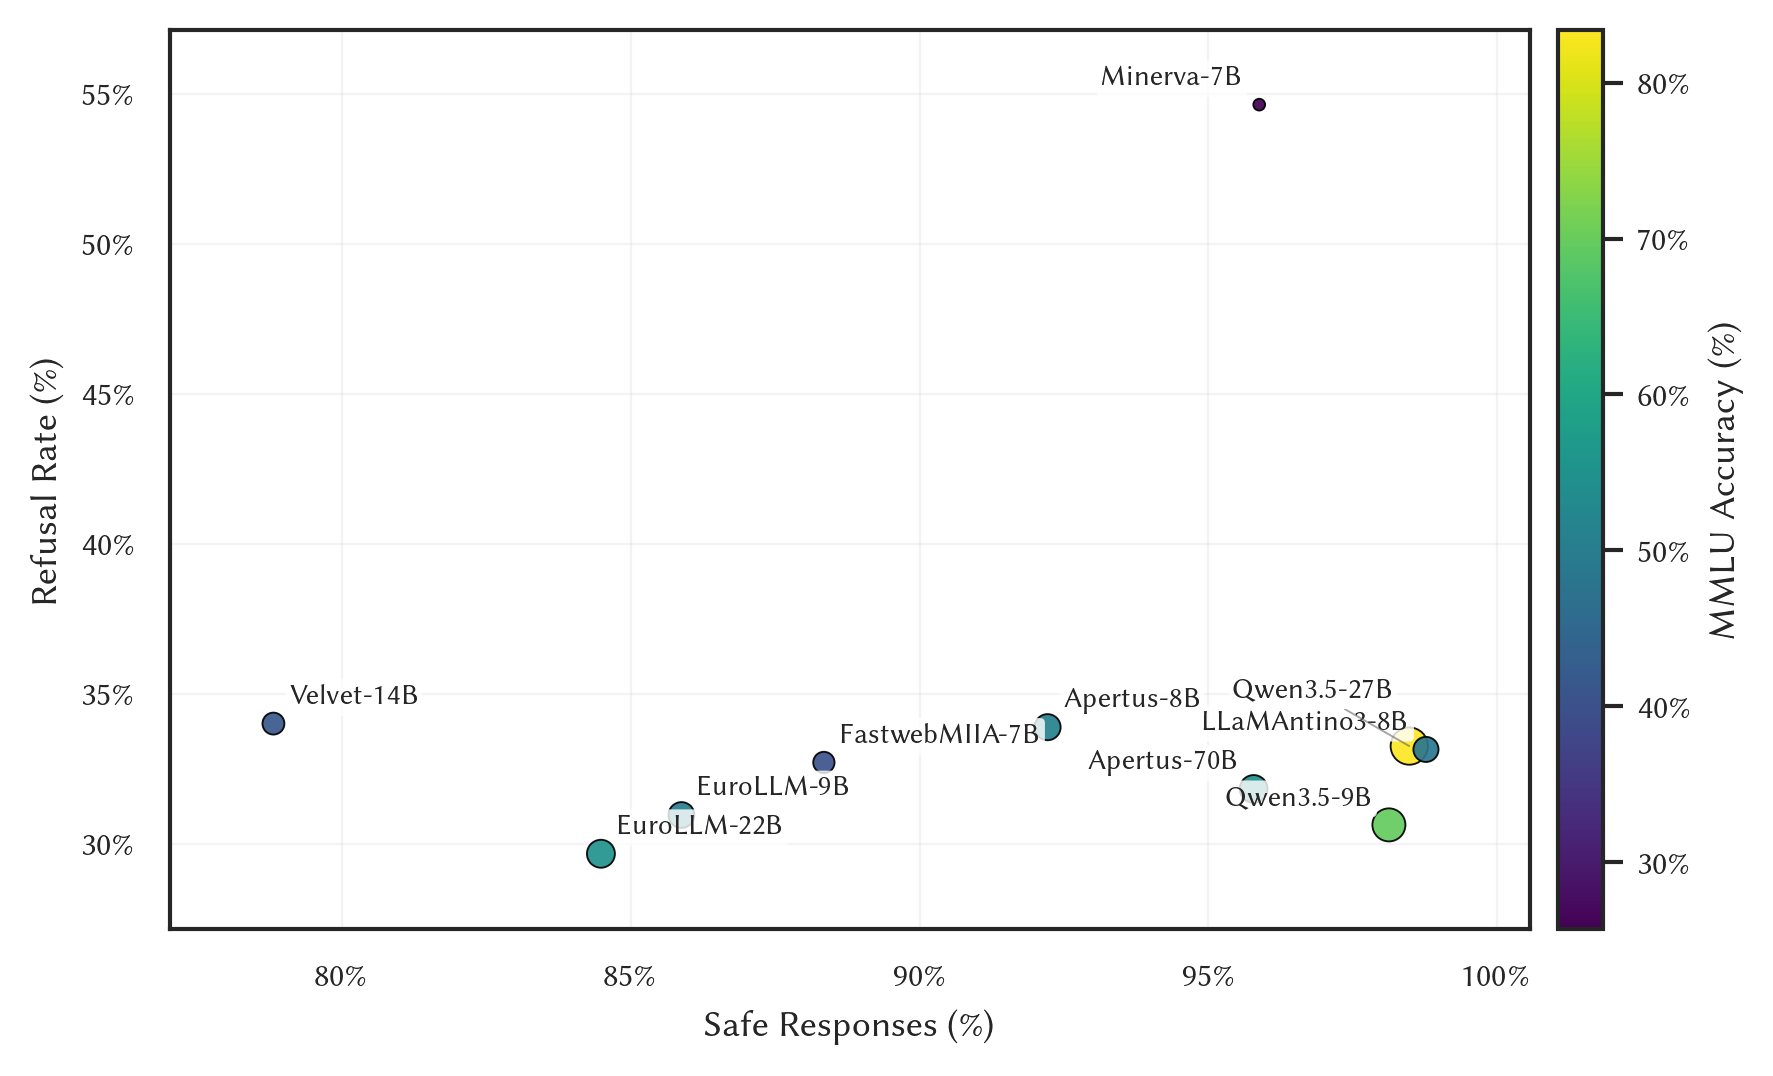

,model,accuracy_pct,refused_pct,safe_pct
0,Qwen3.5-27B,83.3905,33.2651,98.4762
1,Qwen3.5-9B,69.6569,30.6397,98.1238
2,EuroLLM-22B,55.3819,29.6778,84.4857
3,Apertus-70B,54.9692,31.8365,95.7825
4,Apertus-8B,50.7666,33.8952,92.2159
5,EuroLLM-9B,50.1555,30.9683,85.8794
6,LLaMAntino3-8B,48.4455,33.1540,98.7651
7,Velvet-14B,41.4929,34.0143,78.8175
8,FastwebMIIA-7B,40.2975,32.7190,88.3444
9,Minerva-7B,25.7438,54.6365,95.8794


In [484]:
model_view = make_profile_view(corr_df, "model")

plot_profile_scatter(
    view=model_view,
    label_col="model",
    title="",
    filename_stem=f"correlation_model_profile_{output_suffix}",
    size_range=(8, 80),
)

model_view

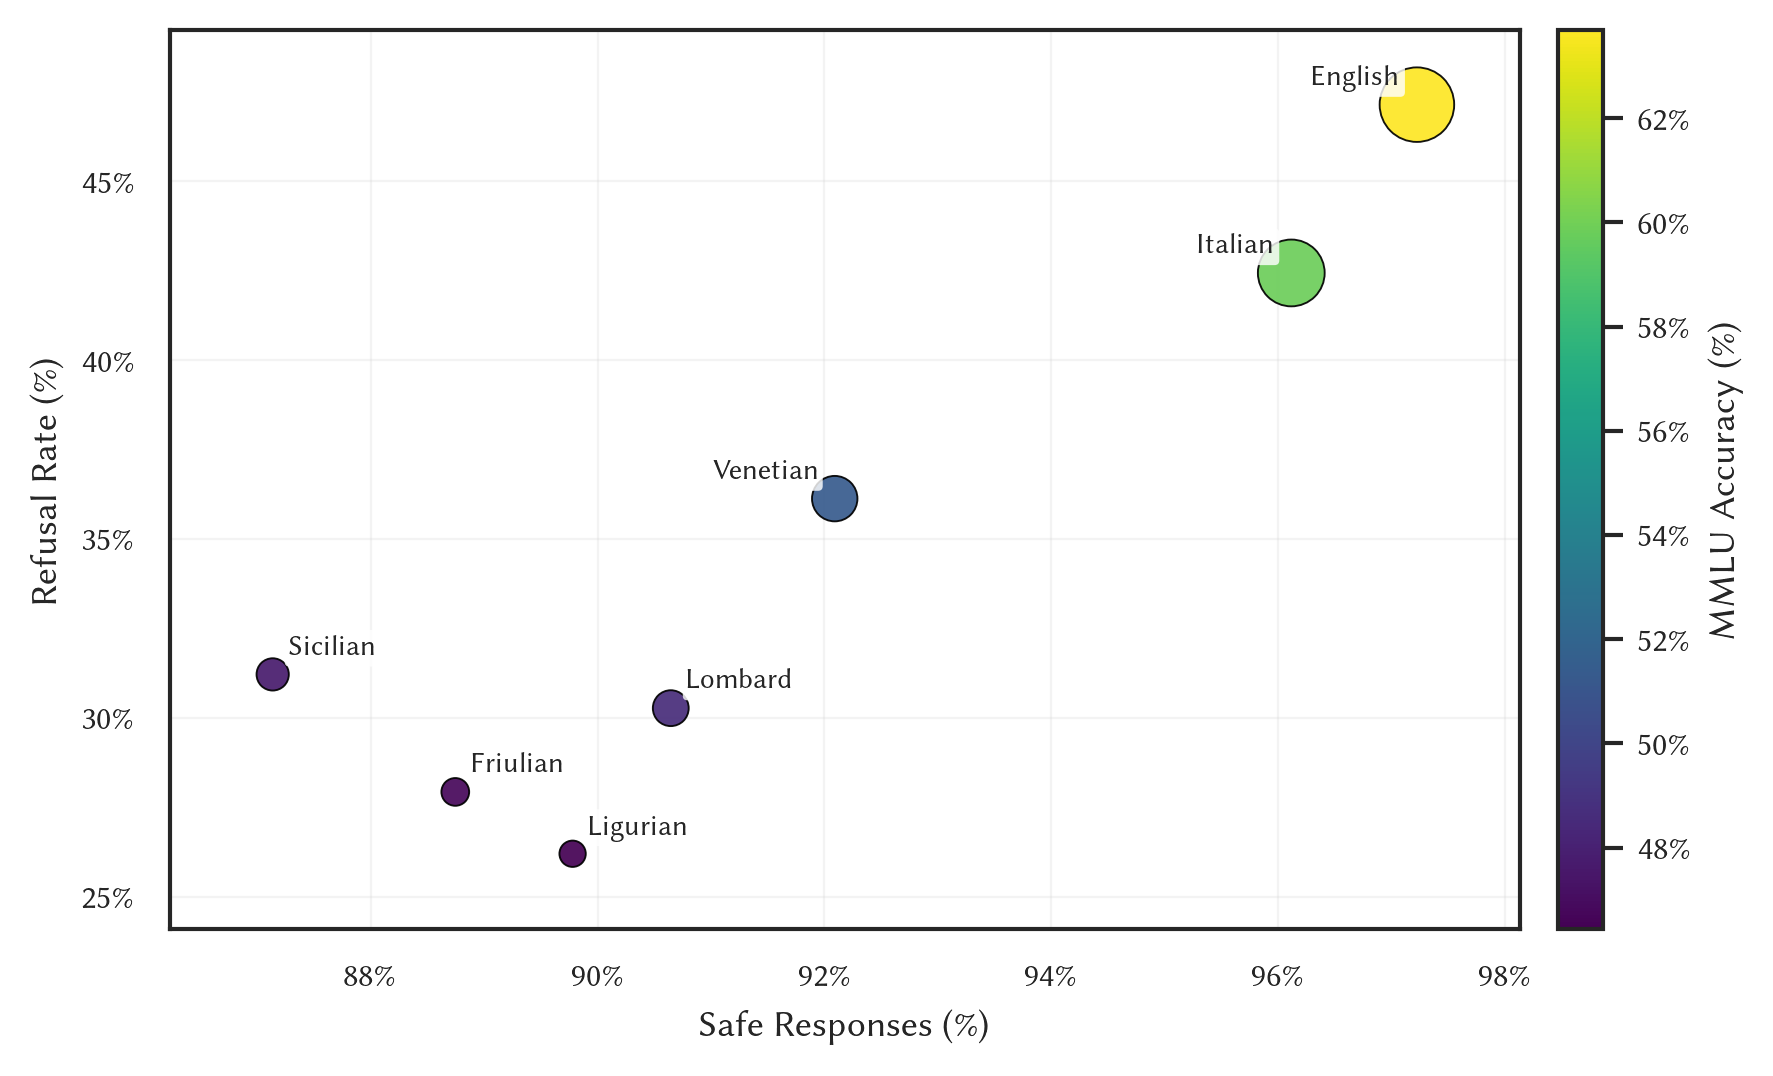

,lang,accuracy_pct,refused_pct,safe_pct,n_models
0,English,63.6998,47.1411,97.2244,10
1,Italian,59.8161,42.4389,96.1167,10
2,Venetian,51.3096,36.1333,92.0911,10
3,Lombard,48.5460,30.2789,90.6456,10
4,Sicilian,47.6773,31.2222,87.1356,10
5,Friulian,46.7167,27.9389,88.7456,10
6,Ligurian,46.4447,26.2111,89.7800,10


In [485]:
language_view = make_profile_view(corr_df, "lang")
language_view["n_models"] = (
    corr_df.groupby("lang", observed=False)["model"].nunique().reindex(language_view["lang"]).values
)

plot_profile_scatter(
    view=language_view,
    label_col="lang",
    title="",
    filename_stem=f"correlation_language_profile_{output_suffix}",
    size_range=(40, 320),
)

language_view

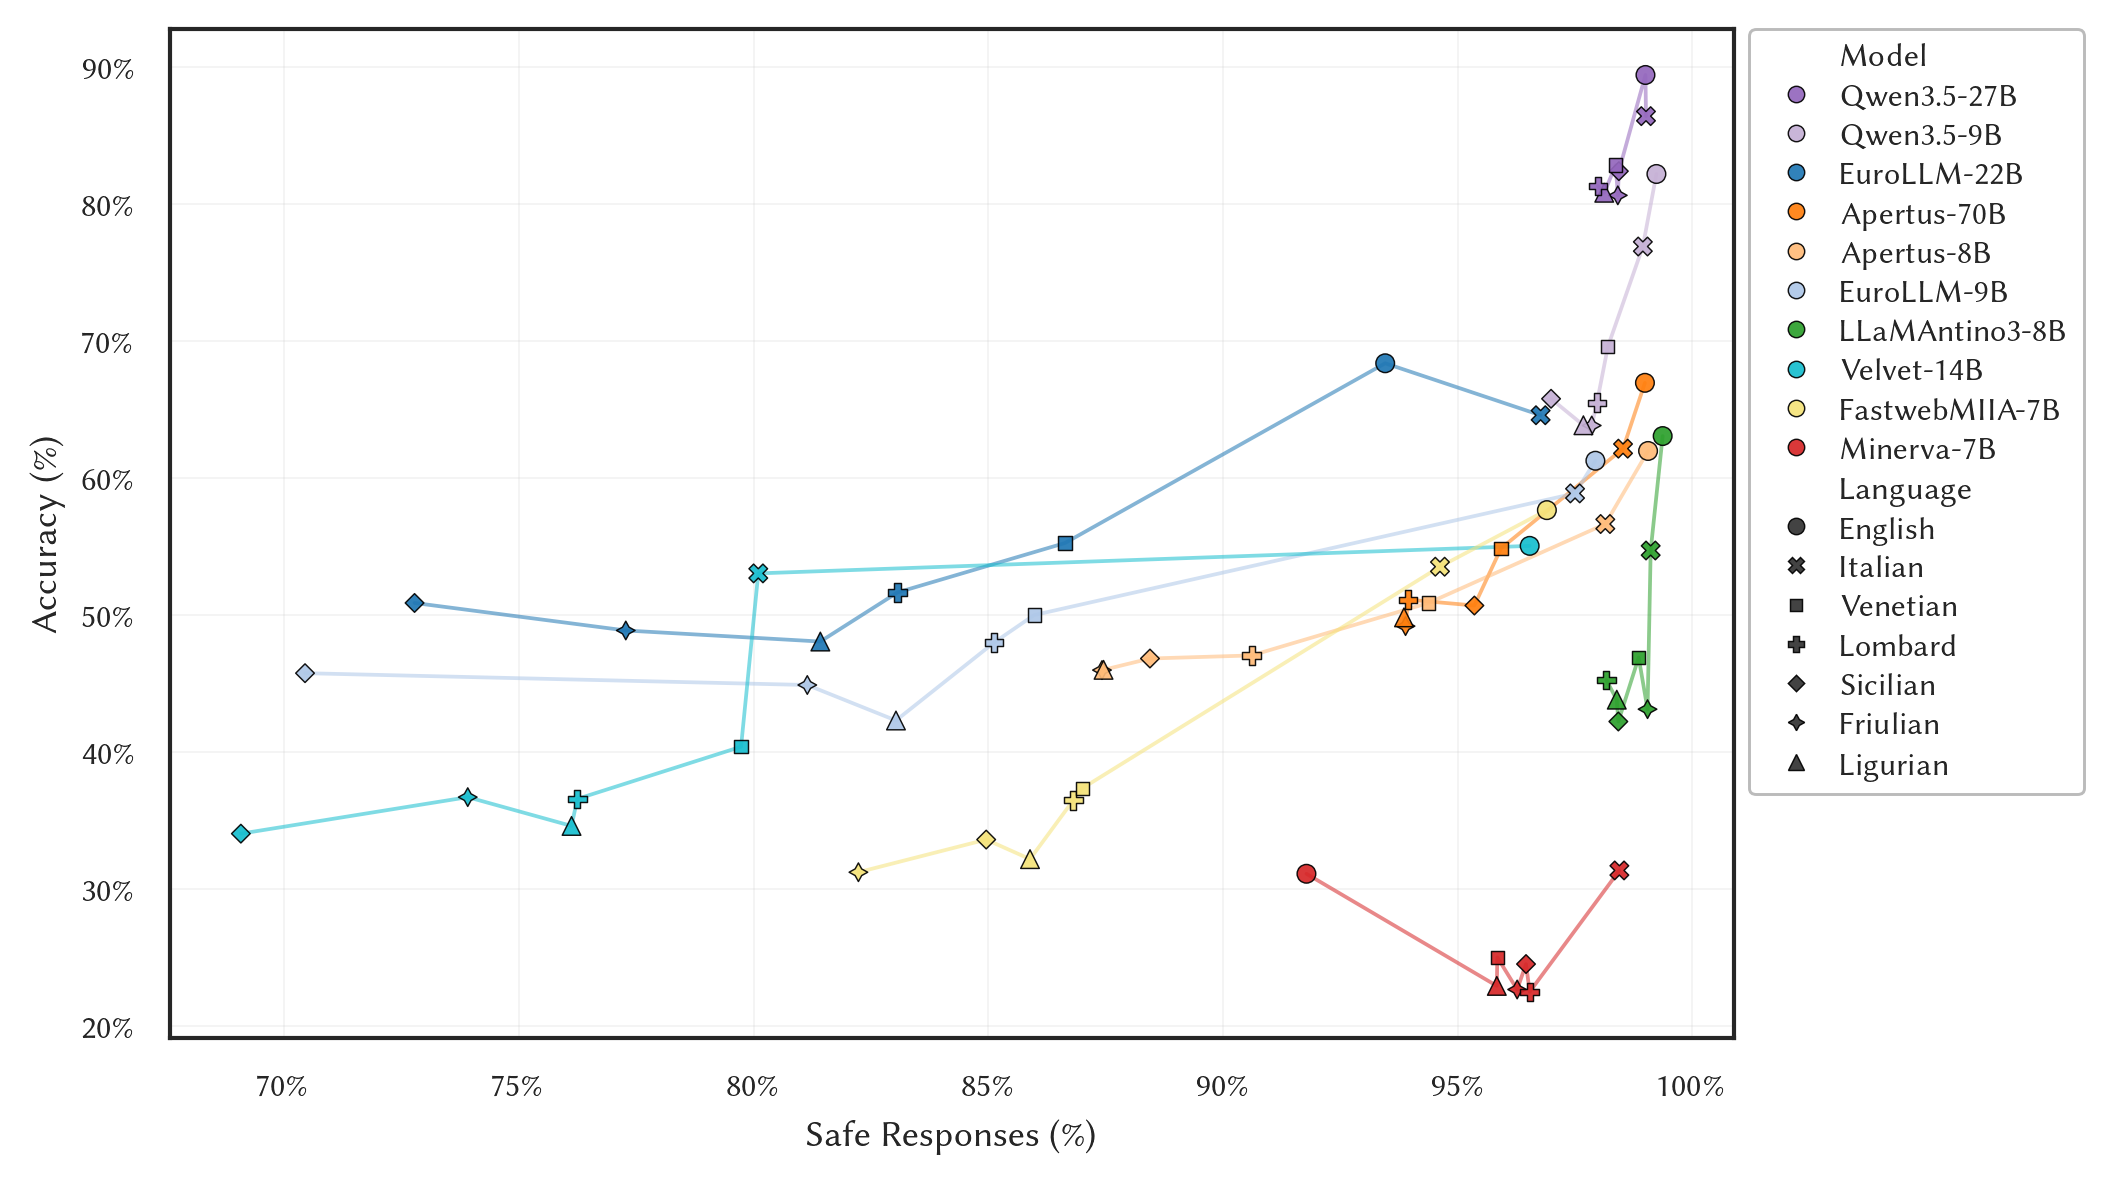

In [486]:
plot_accuracy_vs_metric(
    data=corr_df,
    x_col=safe_pct_col,
    x_label=r"Safe Responses (\%)",
    title="",
    filename_stem=f"correlation_accuracy_vs_safe_pct_by_language_lines_{output_suffix}",
)

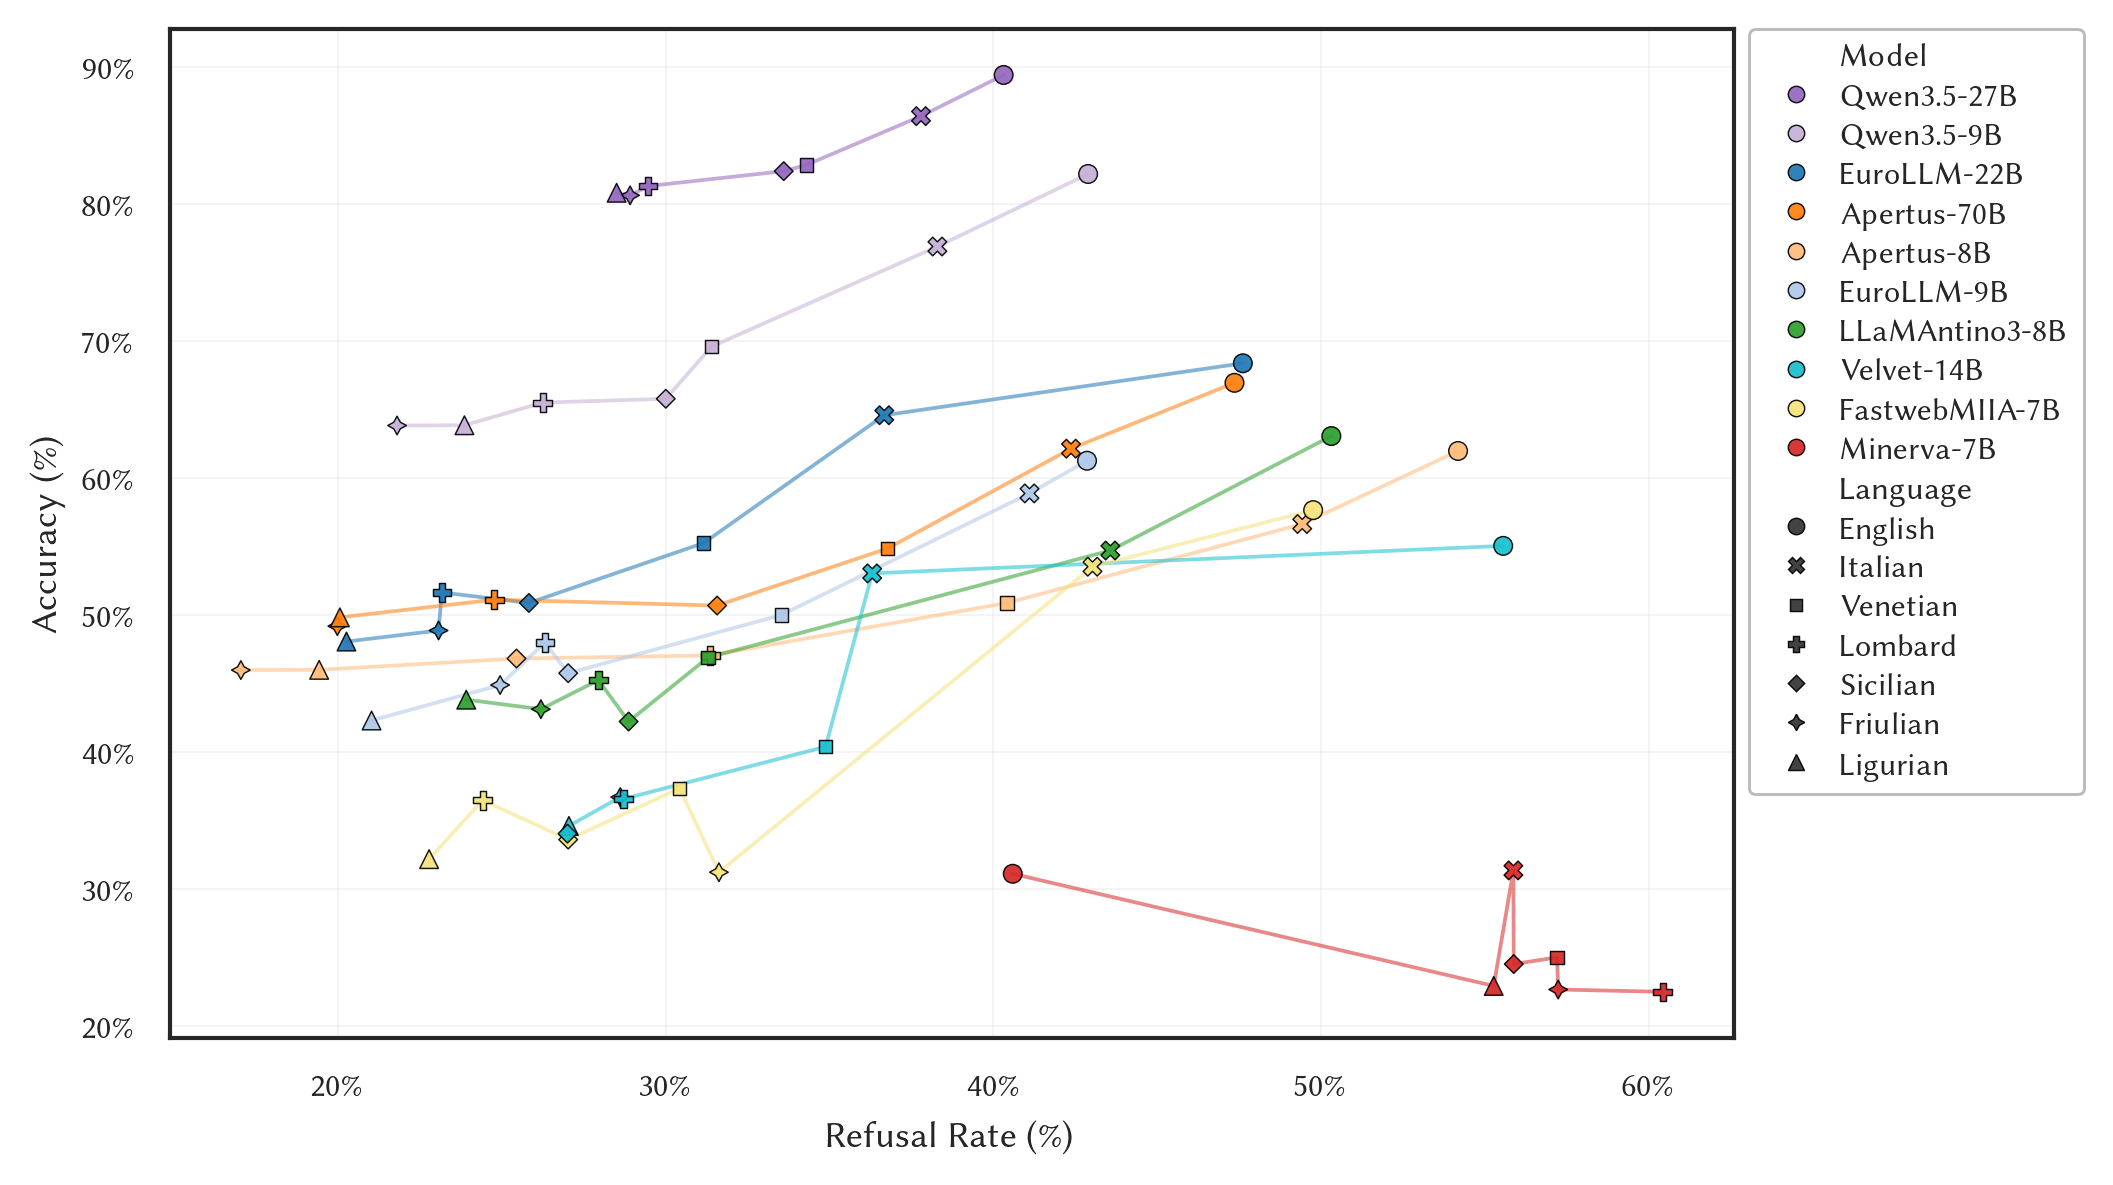

In [487]:
plot_accuracy_vs_metric(
    data=corr_df,
    x_col=refused_pct_col,
    x_label=r"Refusal Rate (\%)",
    title="",
    filename_stem=f"correlation_accuracy_vs_refused_pct_by_language_lines_{output_suffix}",
)

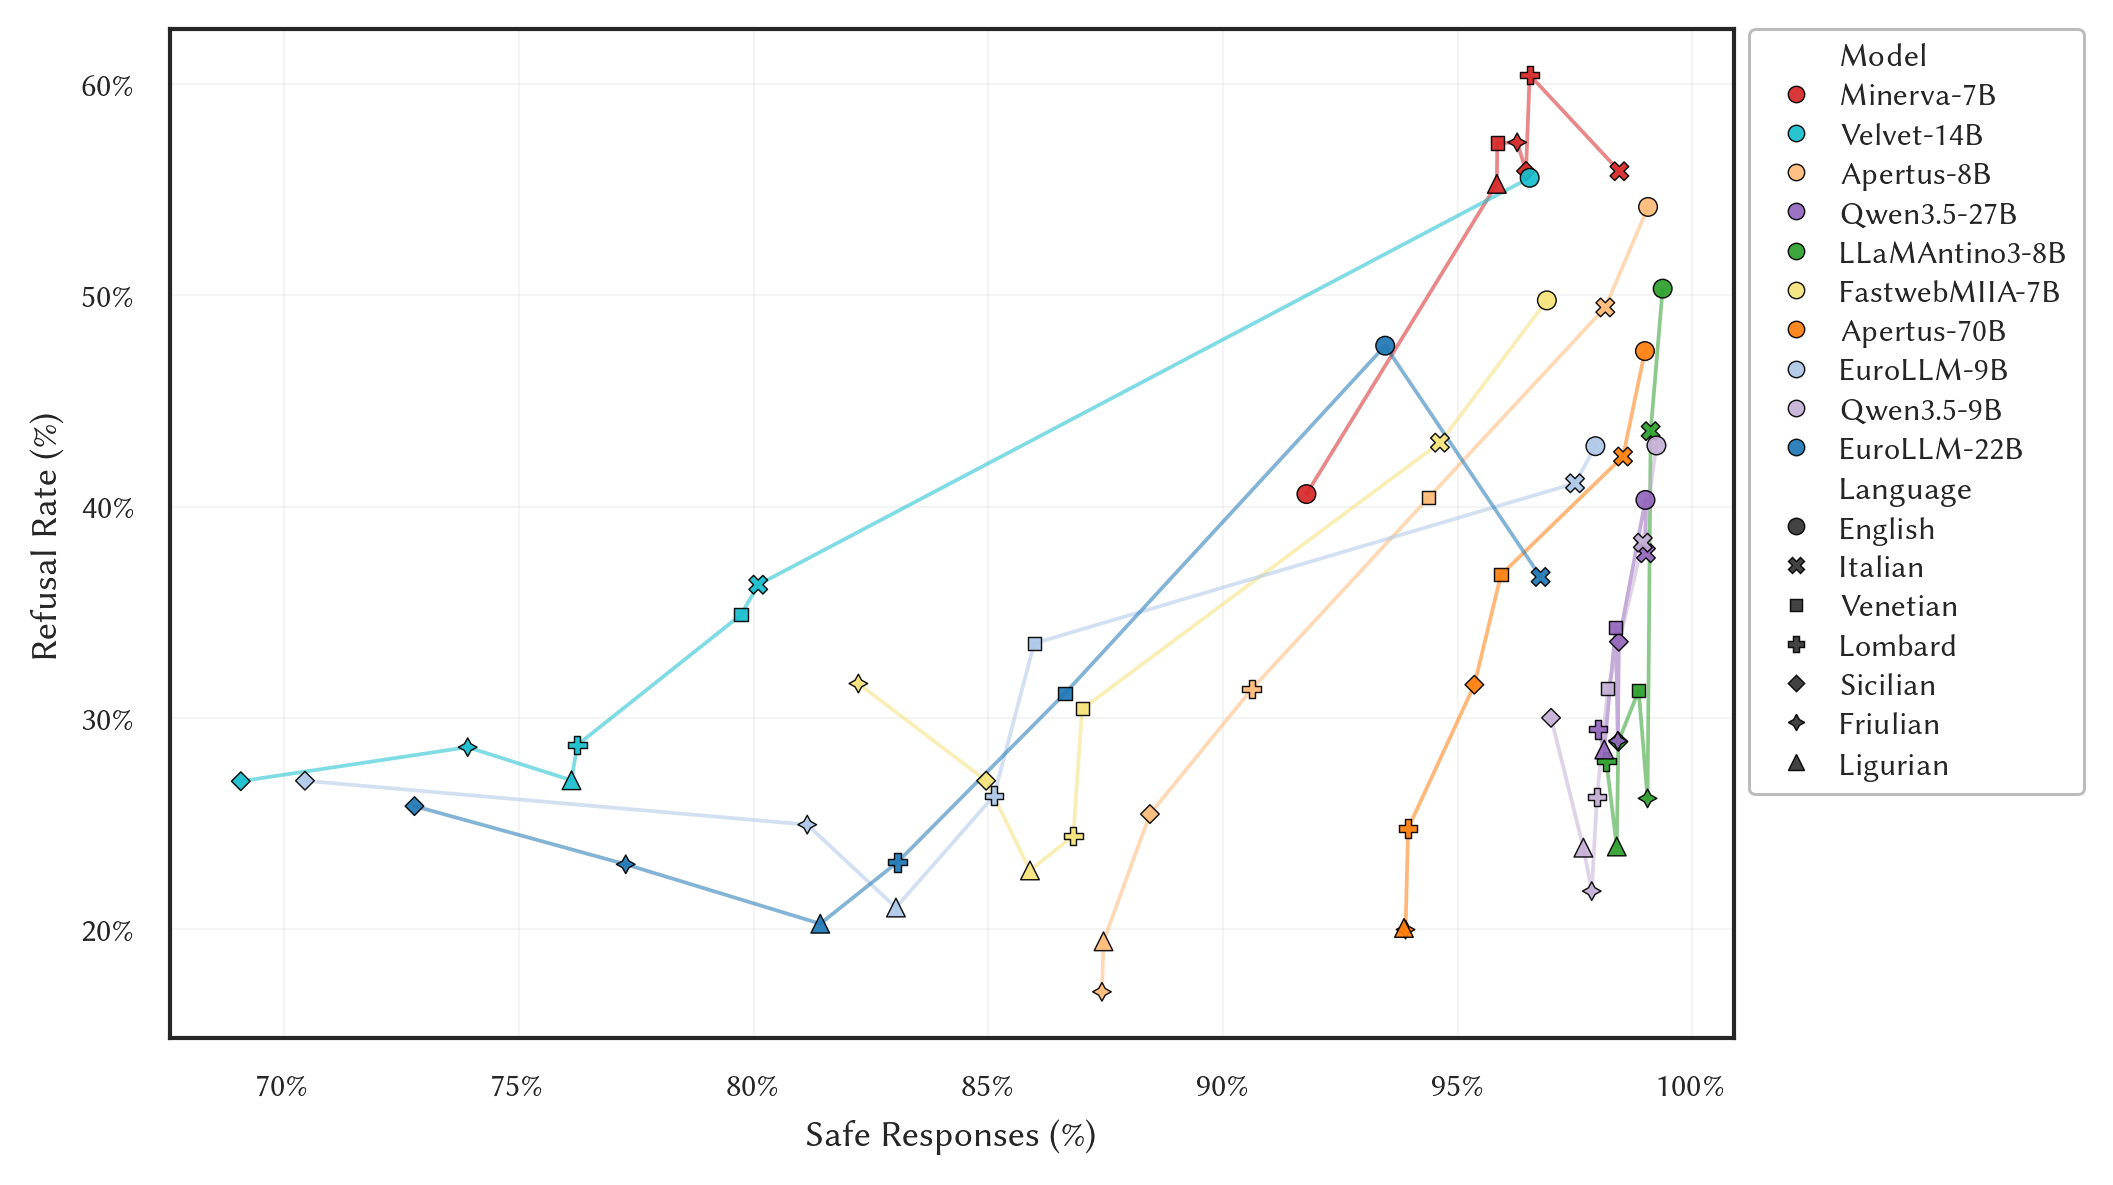

In [488]:
plot_refused_vs_safe_pct(data=corr_df)

In [489]:
df_lang_corr = correlation_by_group(
    data=corr_df,
    group_col="lang",
    feature_col=non_safe_pct_col,
)

df_model_corr = correlation_by_group(
    data=corr_df,
    group_col="model",
    feature_col=non_safe_pct_col,
)

corr_results.to_csv(EXPORT_DIR / f"correlation_overall_metrics_{output_suffix}.csv", index=False)
df_lang_corr.to_csv(EXPORT_DIR / f"correlation_by_language_{output_suffix}.csv", index=False)
df_model_corr.to_csv(EXPORT_DIR / f"correlation_by_model_{output_suffix}.csv", index=False)
corr_df.to_csv(EXPORT_DIR / f"correlation_joined_metrics_{output_suffix}.csv", index=False)

print("Saved correlation outputs:")
print(f"- {EXPORT_DIR / f'correlation_overall_metrics_{output_suffix}.csv'}")
print(f"- {EXPORT_DIR / f'correlation_by_language_{output_suffix}.csv'}")
print(f"- {EXPORT_DIR / f'correlation_by_model_{output_suffix}.csv'}")
print(f"- {EXPORT_DIR / f'correlation_joined_metrics_{output_suffix}.csv'}")

Saved correlation outputs:
- ../outputs/correlation_data/correlation_overall_metrics_overall.csv
- ../outputs/correlation_data/correlation_by_language_overall.csv
- ../outputs/correlation_data/correlation_by_model_overall.csv
- ../outputs/correlation_data/correlation_joined_metrics_overall.csv
